In [1]:
import pandas as pd
import numpy as np

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from tabulate import tabulate
from SQUIC_functions import *

In [2]:
# DATASET = "../datasets/AMLSim/1K user"

accounts = pd.read_csv('accounts.csv')
transactions = pd.read_csv('transactions.csv')

In [3]:
# Create root
balances = {}

# Take users data from account.csv
for _, row in accounts.iterrows():
    acc_id = row["ACCOUNT_ID"] # User id
    open_date = 0
    initial_balance = round(float(row["INIT_BALANCE"]), 2)

    balances[acc_id] = [{"date": open_date,
                         "balance": initial_balance
                        }]
    
    if acc_id == 0: # Check
        print("first user must be 0 => ",str(acc_id))
        print("user 0 initial deposit must be 184.44 => ", initial_balance)

first user must be 0 =>  0
user 0 initial deposit must be 184.44 =>  184.44


In [4]:
transactions['TX_TYPE'].unique()

array(['TRANSFER'], dtype=object)

In [5]:
# Apply transactions to users' balances
transactions.sort_values(by="TX_ID")

# Track the last balance for each account
current_balances = {acct_id: balances[acct_id][0]["balance"] for acct_id in balances}

for i, (_, row) in enumerate(transactions.iterrows()):
    orig_acct = row["SENDER_ACCOUNT_ID"]
    bene_acct = row["RECEIVER_ACCOUNT_ID"]
    amount = row["TX_AMOUNT"]
    tx_type = row['TX_TYPE']
    date = row["TIMESTAMP"]

    if orig_acct in balances: # check that sender has a deposit
        last_balance = balances[orig_acct][-1]["balance"] # read balance from balances
        if tx_type in ['TRANSFER', 'WITHDRAWAL']: # all TRANSFER in the csv
            new_balance = last_balance - amount

        balances[orig_acct].append({"date": date, "balance": round(new_balance, 2)})
            
    
    if bene_acct in balances: # check that receiver has a deposit
        last_balance = balances[bene_acct][-1]["balance"]
        if tx_type in ['TRANSFER', 'DEPOSIT']:
            new_balance = last_balance + amount

        balances[bene_acct].append({"date": date, "balance": round(new_balance, 2)})
            

In [6]:
len(balances)

10000

In [7]:
for i, (acct_id, account_data) in enumerate(balances.items()):
    if i < 1:
        print(acct_id)
        print(account_data)
        break

0
[{'date': 0, 'balance': 184.44}]


In [8]:
result = []

for date in sorted(set(transactions["TIMESTAMP"])):
    daily_balances = {
        "date": date,
        "balances": {
            str(user): {
                "balance": next((entry["balance"] for entry in reversed(b) if entry["date"] <= date), b[0]["balance"])
            } for user, b in balances.items()}
    }
    result.append(daily_balances)

In [9]:
df = pd.DataFrame(result)

# Unpack 'balances' into separate columns for each user
df = df.join(pd.DataFrame(df['balances'].tolist()))

df.drop('balances', axis=1, inplace=True)
df.set_index('date', inplace=True)
df.drop('_id', axis=1, inplace=True, errors='ignore')

for col in df.columns:
    df[col] = df[col].apply(lambda x: x['balance'] if isinstance(x, dict) else x)

In [10]:
#df = pd.DataFrame([{**entry["balances"], "date": entry["date"]} for entry in data])

#print(df.shape) # must be (720, 1447)
#print(df.head())

#      | id1 | id2 | ... | id1446
# day1 |   
# day2 |        balances
# ...

In [11]:
df

,0,1,2,3,4,5,6,7,8,9,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
date,,,,,,,,,,,,,,,,,,,,,
0,184.44,175.8,142.06,125.89,151.13,140.49,178.38,130.33,147.66,158.34,...,1.146210e+03,7.903200e+02,2.770150e+03,3.074230e+03,3.122300e+03,7.710300e+02,8.160900e+02,1.113220e+03,2.505310e+03,1.361130e+03
1,184.44,175.8,142.06,125.89,151.13,140.49,369.57,0.01,147.66,158.34,...,2.244260e+03,-1.484520e+03,5.821460e+03,6.989780e+03,6.556470e+03,9.088400e+02,1.579460e+03,2.093740e+03,4.695210e+03,3.082930e+03
2,184.44,175.8,142.06,125.89,151.13,148.74,369.57,0.01,147.66,158.34,...,2.627990e+03,9.538000e+01,7.941430e+03,1.276509e+04,1.000653e+04,2.264190e+03,2.739510e+03,2.767220e+03,7.006600e+03,4.094660e+03
3,184.44,175.8,142.06,125.89,151.13,148.74,369.57,0.01,147.66,158.34,...,2.773680e+03,1.811320e+03,1.193886e+04,1.985444e+04,1.449974e+04,3.341060e+03,3.673850e+03,3.145260e+03,9.319790e+03,5.740210e+03
4,184.44,175.8,142.06,125.89,151.13,148.74,369.57,0.01,147.66,0.02,...,3.753940e+03,4.622490e+03,1.403018e+04,2.427739e+04,1.857337e+04,4.321930e+03,4.249540e+03,3.675470e+03,1.114373e+04,6.627840e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,184.44,-3691.8,-2272.79,-1826.46,-3324.86,-2371.88,612.96,590.66,-3248.52,9476994.02,...,1.744558e+08,1.858088e+08,1.807265e+08,2.385128e+08,1.876246e+08,2.425374e+08,4.258409e+08,3.369211e+08,4.133597e+08,3.522696e+08
196,184.44,-3691.8,-2272.79,-1826.46,-3324.86,-2371.88,612.96,590.66,-3248.52,9476994.02,...,1.925790e+08,1.858104e+08,1.807289e+08,2.385184e+08,1.876290e+08,2.818782e+08,4.258418e+08,3.369215e+08,4.133576e+08,3.522715e+08
197,184.44,-3691.8,-2414.84,-1952.34,-3324.86,-2371.88,612.96,590.66,-3248.52,9476994.02,...,1.925814e+08,1.858109e+08,1.924960e+08,2.599992e+08,1.876324e+08,2.818789e+08,4.463646e+08,3.369225e+08,4.133600e+08,3.522725e+08


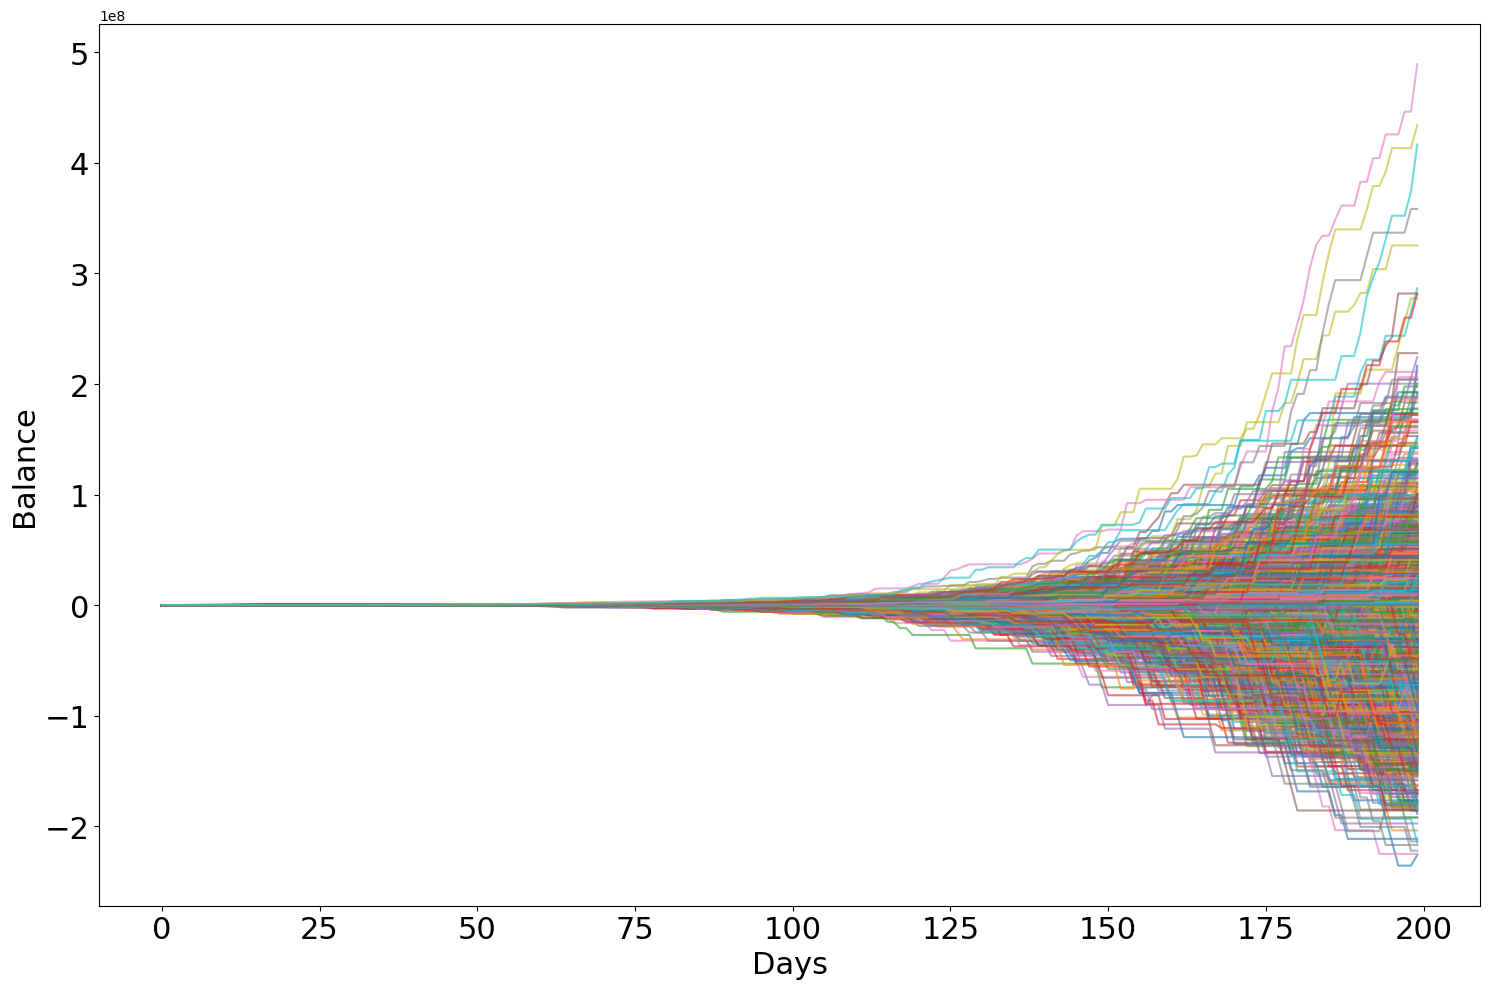

In [12]:
# Plot the balance evolution for all users (columns) as separate lines
# plt.figure(figsize=(15,10), dpi= 300)
plt.figure(figsize=(15,10))

# Plot each column (account balance) as a line
for user in df.columns:
    plt.plot(df.index, df[user], label=f"User {user}", alpha=0.6)

# Add title and labels
# plt.title("Balance Evolution of Users Over Time")
plt.xlabel("Days", fontsize=22)
plt.ylabel("Balance", fontsize=22)

# Rotate x-axis labels for better visibility
#plt.xticks(rotation=45)
plt.tick_params(axis='x', labelsize=22)
plt.tick_params(axis='y', labelsize=22)

# Add legend to differentiate users
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Display the plot
plt.tight_layout()
plt.show()

# Balance Distribution

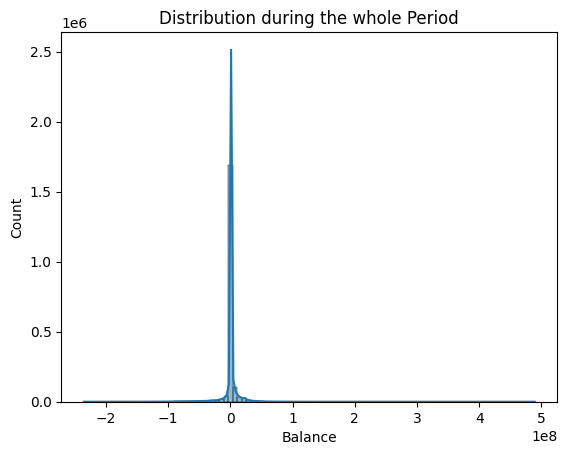

In [13]:
values_df = df.values.flatten()
# Plot distribution for all the days (aggregated over users and days)
sns.histplot(values_df, bins=100, kde=True)
plt.title("Distribution during the whole Period")
plt.xlabel("Balance")
plt.show()

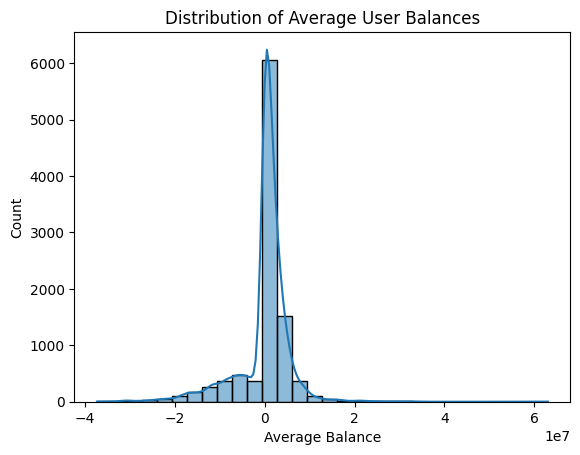

In [14]:
# Compute the mean balance per user over all days
user_means = df.mean(axis=0)

sns.histplot(user_means, bins=30, kde=True)
plt.title("Distribution of Average User Balances")
plt.xlabel("Average Balance")
plt.show()

# Squic

In [15]:
df.T

date,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,184.44,184.44,184.44,184.44,184.44,184.44,184.44,184.44,184.44,184.44,...,1.844400e+02,1.844400e+02,1.844400e+02,1.844400e+02,1.844400e+02,1.844400e+02,1.844400e+02,1.844400e+02,1.844400e+02,1.844400e+02
1,175.80,175.80,175.80,175.80,175.80,175.80,0.00,0.00,0.00,0.00,...,-3.516000e+03,-3.516000e+03,-3.516000e+03,-3.516000e+03,-3.516000e+03,-3.691800e+03,-3.691800e+03,-3.691800e+03,-3.867600e+03,-4.043400e+03
2,142.06,142.06,142.06,142.06,142.06,142.06,142.06,142.06,142.06,142.06,...,-2.130740e+03,-2.130740e+03,-2.130740e+03,-2.130740e+03,-2.130740e+03,-2.272790e+03,-2.272790e+03,-2.414840e+03,-2.414840e+03,-2.414840e+03
3,125.89,125.89,125.89,125.89,125.89,125.89,125.89,125.89,125.89,125.89,...,-1.700580e+03,-1.700580e+03,-1.700580e+03,-1.826460e+03,-1.826460e+03,-1.826460e+03,-1.826460e+03,-1.952340e+03,-1.952340e+03,-1.952340e+03
4,151.13,151.13,151.13,151.13,151.13,151.13,151.13,151.13,151.13,151.13,...,-2.871470e+03,-3.022600e+03,-3.022600e+03,-3.173730e+03,-3.324860e+03,-3.324860e+03,-3.324860e+03,-3.324860e+03,-3.324860e+03,-3.324860e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771.03,908.84,2264.19,3341.06,4321.93,4817.24,5448.45,6223.93,6769.49,7289.85,...,1.996083e+08,1.996085e+08,2.210844e+08,2.210854e+08,2.345277e+08,2.425374e+08,2.818782e+08,2.818789e+08,2.818795e+08,2.818800e+08
9996,816.09,1579.46,2739.51,3673.85,4249.54,8480.05,9445.72,10415.13,11817.49,12038.68,...,3.828913e+08,3.828921e+08,4.043640e+08,4.043649e+08,4.258403e+08,4.258409e+08,4.258418e+08,4.463646e+08,4.463618e+08,4.893075e+08
9997,1113.22,2093.74,2767.22,3145.26,3675.47,1785.52,3393.54,6967.48,8576.24,9833.64,...,2.939678e+08,3.154443e+08,3.369197e+08,3.369201e+08,3.369206e+08,3.369211e+08,3.369215e+08,3.369225e+08,3.583986e+08,3.584002e+08
9998,2505.31,4695.21,7006.60,9319.79,11143.73,14179.16,16853.60,19154.32,21394.59,27401.59,...,3.398472e+08,3.576590e+08,3.791368e+08,3.791384e+08,3.918822e+08,4.133597e+08,4.133576e+08,4.133600e+08,4.133623e+08,4.341127e+08


In [16]:
ROWS = len(df.iloc[0])
ROWS

10000

## Squic DF

### Non normalized

In [17]:
# Y = df.T.to_numpy()  # Transpose to get shape (users, days)

In [18]:
# squic_dict = {}

In [19]:
# l = [9e-1, 5e-1, 2e-1, 1e-1, 9e-2, 5e-2, 1e-2, 9e-3, 5e-3, 1e-3, 1e-4]

In [20]:
# data_nnz = []
# data_nnzr = []
# data_time = []
# data_sym = []

# for rho in l:
#     X, computation_time = compute_squic(Y, rho)
#     computation_time = round(computation_time, 2)
#     squic_dict[rho] = X
#     print(f"time required: {computation_time} seconds")

#     nonz, nonz_r = count_nnz(squic_dict[rho], ROWS)

#     if is_symmetric(squic_dict[rho]):
#         print(f"✅ Matrix is symmetric per rho {rho}")
#         data_sym.append('Yes')
#     else:
#         print(f"❌ Matrix is not symmetric per rho {rho}")
#         data_sym.append('No')

#     data_nnz.append(nonz)
#     data_nnzr.append(nonz_r)
#     data_time.append(computation_time)

#     if nonz == ROWS:
#         print(f"For rho = {rho} just element on the diagonal")
#         sparsity_pattern(squic_dict[rho])
#     elif nonz == ROWS * ROWS:
#         print(f"For rho = {rho} big dense matrix")
#         sparsity_pattern(squic_dict[rho])
#         print(f"nnz = {nonz}")
#         print(f"nnz/row = {nonz_r}")
#     else:
#         print(f"For rho = {rho} there are some nnz")
#         sparsity_pattern(squic_dict[rho])
#         print(f"nnz = {nonz}")
#         print(f"nnz/row = {nonz_r}")
        

# table_squic = [
#     ["NNZ"] + data_nnz,
#     ["NNZ/Row"] + data_nnzr,
#     ["Time (s)"] + data_time,
#     ["Symmetric"] + data_sym
# ]

### Normalization

In [21]:
squic_norm_dict = {}

In [22]:
Y = df.T.to_numpy()
# normalize the Y input data to achieve unit variance
Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation
# normalizes each row so that the std dev of each user's balance over the days becomes 1

# Y_new has shape (Users × Days).
# S will have shape (Users × Users).

# double check if this is correct by 
S = np.cov(Y_new, bias=True) # "bias=true" you force cove to use n samples instead of n-1

/var/folders/s6/4jprwbqj4012tkll2ww6r5hr0000gq/T/ipykernel_5570/3409128255.py:3: RuntimeWarning: divide by zero encountered in divide
  Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation
/opt/anaconda3/envs/bank/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


In [23]:
print("NaNs?", np.isnan(Y_new).any())
print("Infs?", np.isinf(Y_new).any())
print("Max:", np.max(Y_new))
print("Min:", np.min(Y_new))
print("Mean std per row (should be 1):", round(np.mean(np.std(Y_new, axis=1)), 2))

NaNs? False
Infs? True
Max: inf
Min: -10.533117096273932
Mean std per row (should be 1): nan


/opt/anaconda3/envs/bank/lib/python3.10/site-packages/numpy/_core/_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


In [24]:
# Original code
Y = df.T.to_numpy()

# Check for rows with zero standard deviation
std_values = np.std(Y, axis=1)
zero_std_rows = np.where(std_values == 0)[0]
if len(zero_std_rows) > 0:
    print(f"Warning: {len(zero_std_rows)} rows have zero standard deviation")
    print(f"Zero std rows indices: {zero_std_rows}")

# Option 1: Add a small epsilon to prevent division by zero
epsilon = 1e-10
std_values_safe = np.maximum(std_values, epsilon)
Y_new = np.diag(1/std_values_safe) @ Y

# Option 2: Alternative - skip normalization for constant rows
# std_values_safe = std_values.copy()
# std_values_safe[std_values == 0] = 1.0  # Will keep those rows unchanged
# Y_new = np.diag(1/std_values_safe) @ Y

# Verify the result
print("NaNs?", np.isnan(Y_new).any())
print("Infs?", np.isinf(Y_new).any())
print("Max:", np.max(Y_new[np.isfinite(Y_new)]))  # Only consider finite values
print("Min:", np.min(Y_new[np.isfinite(Y_new)]))  # Only consider finite values
print("Mean std per row (excluding constant rows):", 
      round(np.mean(np.std(Y_new[std_values > 0], axis=1)), 2))

# Calculate covariance properly
S = np.cov(Y_new, bias=True)

Zero std rows indices: [0]
NaNs? False
Infs? False
Max: 1844400000000.0
Min: -10.533117096273932
Mean std per row (excluding constant rows): 1.0


In [28]:
#l = [9e-1, 5e-1, 2e-1, 1e-1, 9e-2, 5e-2, 1e-2, 9e-3, 5e-3, 1e-3, 1e-4]
# l = [95e-2, 9e-1, 85e-2, 8e-1, 75e-2, 7e-1, 65e-2, 6e-1, 55e-2, 5e-1]
# at 0.95 is very dense yet

# l = [9e-1, 8e-1, 7e-1, 6e-1]

#l = [0.9999, 0.999, 0.998, 0.997, 0.995, 0.99]

l = [0.999999, 0.999995, 0.99999, 0.9999]

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           10000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.999990e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=6.66e-02 nnz(S)/p=1.17e+00
* iter=1 time=1.60e-02 obj=1.69e+04 |delta(obj)|/obj=4.09e-01 nnz(X,L,W)/p=[1.17e+00 6.30e-01 1.00e+00] lns_iter=2 
* iter=2 time=1.99e-02 obj=1.69e+04 |delta(obj)|/obj=1.59e-13 nnz(X,L,W)/p=[1.17e+00 6.30e-01 1.00e+00] lns_iter=1 
#SQUIC Finished: time=1.05e-01 nnz(X,W)/p=[1.17e+

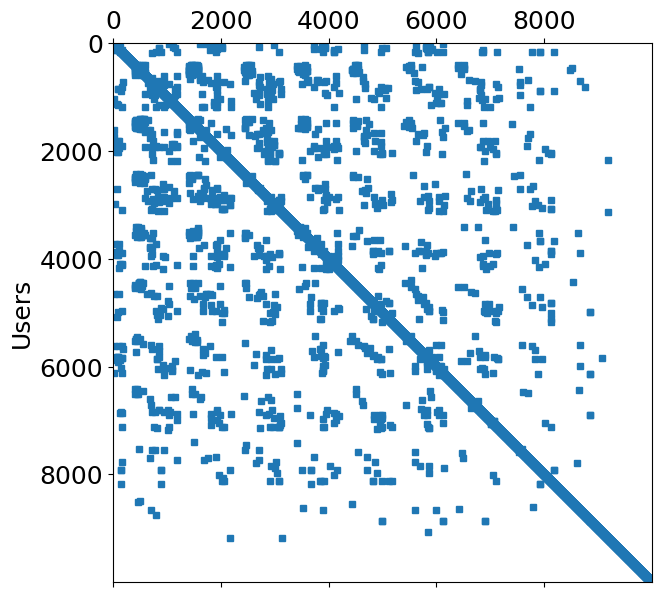

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           10000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.999950e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=7.10e-02 nnz(S)/p=1.82e+00
* iter=1 time=1.73e-02 obj=1.69e+04 |delta(obj)|/obj=4.09e-01 nnz(X,L,W)/p=[1.82e+00 1.07e+00 1.00e+00] lns_iter=2 
* iter=2 time=2.20e-02 obj=1.69e+04 |delta(obj)|/obj=2.14e-13 nnz(X,L,W)/p=[1.82e+00 1.07e+00 1.00e+00] lns_iter=1 
#SQUIC Finished: time=1.13e-01 nnz(X,W)/p=[1.82e+

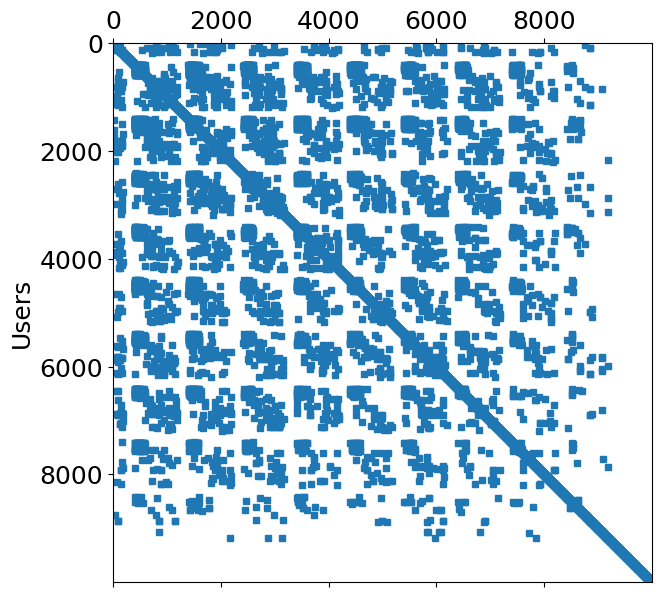

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           10000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.999900e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=6.48e-02 nnz(S)/p=2.40e+00
* iter=1 time=1.92e-02 obj=1.69e+04 |delta(obj)|/obj=4.09e-01 nnz(X,L,W)/p=[2.40e+00 1.48e+00 1.00e+00] lns_iter=2 
* iter=2 time=2.24e-02 obj=1.69e+04 |delta(obj)|/obj=0.00e+00 nnz(X,L,W)/p=[2.40e+00 1.48e+00 1.00e+00] lns_iter=1 
#SQUIC Finished: time=1.08e-01 nnz(X,W)/p=[2.40e+

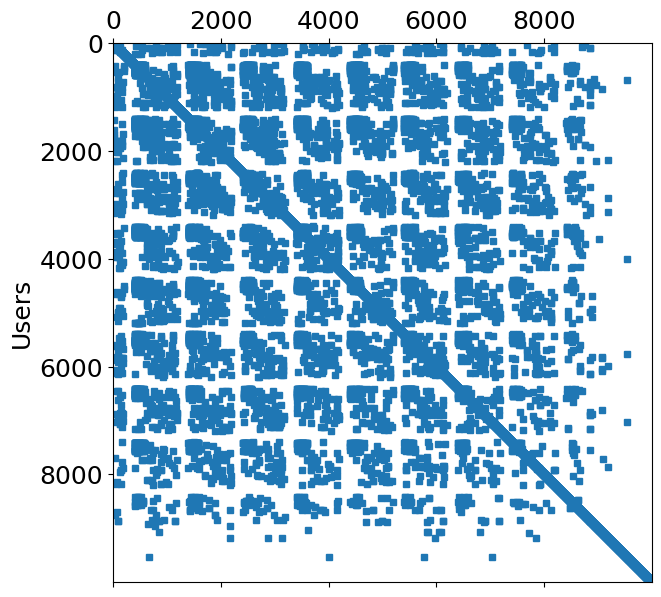

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           10000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.999000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=7.12e-02 nnz(S)/p=2.09e+01
* iter=1 time=4.42e-02 obj=1.69e+04 |delta(obj)|/obj=4.09e-01 nnz(X,L,W)/p=[2.09e+01 1.22e+01 1.00e+00] lns_iter=2 
* iter=2 time=1.32e-01 obj=1.69e+04 |delta(obj)|/obj=0.00e+00 nnz(X,L,W)/p=[2.09e+01 1.22e+01 1.00e+00] lns_iter=1 
#SQUIC Finished: time=2.55e-01 nnz(X,W)/p=[2.09e+

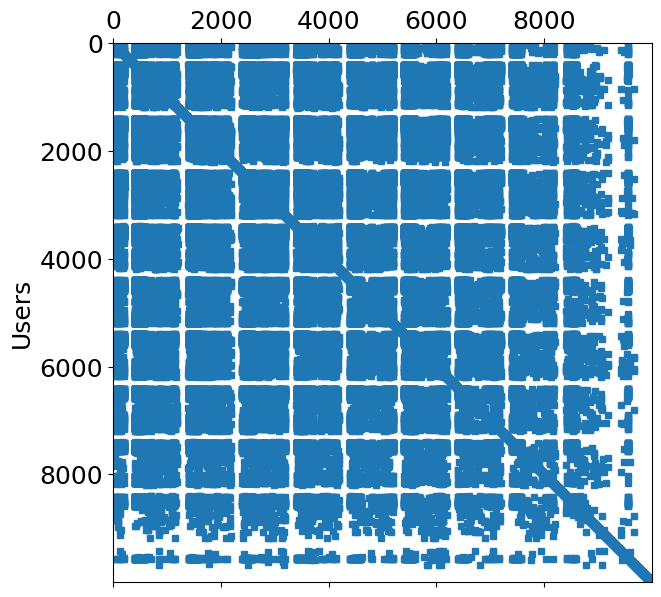

In [29]:
data_nnz = []
data_nnzr = []
data_time = []
data_sym = []

for rho in l:
    X, _, computation_time = compute_squic(Y_new, rho)
    computation_time = round(computation_time, 2)
    squic_norm_dict[rho] = X
    print(f"time required: {computation_time} seconds")

    nonz, nonz_r = count_nnz(squic_norm_dict[rho], ROWS)

    if is_symmetric(squic_norm_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sym.append('Yes')
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sym.append('No')

    data_nnz.append(nonz)
    data_nnzr.append(nonz_r)
    data_time.append(computation_time)

    if nonz == ROWS:
        print(f"For rho = {rho} just element on the diagonal")
        sparsity_pattern(squic_norm_dict[rho])
    elif nonz == ROWS * ROWS:
        print(f"For rho = {rho} big dense matrix")
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
        sparsity_pattern(squic_norm_dict[rho])
    else:
        print(f"For rho = {rho} there are some nnz")
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
        sparsity_pattern(squic_norm_dict[rho])


table_squic_norm = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sym
]

## Squic-FIT

### Non normalized

In [25]:
# fit_dict = {}

In [26]:
# Y = df.T.to_numpy()  # Convert to (users, days)

In [27]:
# l = [9e-1, 5e-1, 2e-1, 1e-1, 9e-2, 5e-2, 1e-2, 9e-3, 5e-3, 1e-3, 1e-4]

In [28]:
# data_nnz = []
# data_nnzr = []
# data_time = []
# data_sym = []

# for rho in l:
#     fit_dict[rho], end_time = squic_fit(Y, lambda_val=rho, eta=rho * 0.1)
#     end_time = round(end_time, 2)
#     print(f"required time: {end_time}")

#     nnz, nnz_r = nnz_fit(fit_dict[rho], ROWS)
#     print(f"nnz = {nnz} per rows = {nnz_r}")

#     if is_symmetric(fit_dict[rho]):
#         print(f"✅ Matrix is symmetric per rho {rho}")
#         data_sym.append("Yes")
#     else:
#         print(f"❌ Matrix is not symmetric per rho {rho}")
#         data_sym.append("No")

#     sparsity_pattern(fit_dict[rho])

#     data_nnz.append(nnz)
#     data_nnzr.append(nnz_r)
#     data_time.append(end_time)

# table_fit = [
#     ["NNZ"] + data_nnz,
#     ["NNZ/Row"] + data_nnzr,
#     ["Time (s)"] + data_time,
#     ["Symmetric"] + data_sym
# ]

### Normalization

In [29]:
# l = [9e-1, 5e-1, 2e-1, 1e-1, 9e-2, 5e-2, 1e-2, 9e-3, 5e-3, 1e-3, 1e-4]
l = [0.9999, 0.999, 0.998, 0.997, 0.995, 0.99]

In [30]:
fit_norm_dict = {}

In [31]:
# normalize the Y input data to achieve unit variance
Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation
# normalizes each row so that the std dev of each user's balance over the days becomes 1

# Y_new has shape (Users × Days).
# S will have shape (Users × Users).

# double check if this is correct by 
S = np.cov(Y_new, bias=True) # "bias=true" you force cove to use n samples instead of n-1

/var/folders/s6/4jprwbqj4012tkll2ww6r5hr0000gq/T/ipykernel_5570/890328076.py:2: RuntimeWarning: divide by zero encountered in divide
  Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation
/opt/anaconda3/envs/bank/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


In [32]:
Y = df.T.to_numpy()

# Check for rows with zero standard deviation
std_values = np.std(Y, axis=1)
zero_std_rows = np.where(std_values == 0)[0]
if len(zero_std_rows) > 0:
    print(f"Warning: {len(zero_std_rows)} rows have zero standard deviation")
    print(f"Zero std rows indices: {zero_std_rows}")

# Option 1: Add a small epsilon to prevent division by zero
epsilon = 1e-10
std_values_safe = np.maximum(std_values, epsilon)
Y_new = np.diag(1/std_values_safe) @ Y

# Option 2: Alternative - skip normalization for constant rows
# std_values_safe = std_values.copy()
# std_values_safe[std_values == 0] = 1.0  # Will keep those rows unchanged
# Y_new = np.diag(1/std_values_safe) @ Y

# Verify the result
print("NaNs?", np.isnan(Y_new).any())
print("Infs?", np.isinf(Y_new).any())
print("Max:", np.max(Y_new[np.isfinite(Y_new)]))  # Only consider finite values
print("Min:", np.min(Y_new[np.isfinite(Y_new)]))  # Only consider finite values
print("Mean std per row (excluding constant rows):", 
      round(np.mean(np.std(Y_new[std_values > 0], axis=1)), 2))

# Calculate covariance properly
S = np.cov(Y_new, bias=True)

Zero std rows indices: [0]
NaNs? False
Infs? False
Max: 1844400000000.0
Min: -10.533117096273932
Mean std per row (excluding constant rows): 1.0


In [33]:
len(Y_new)

10000

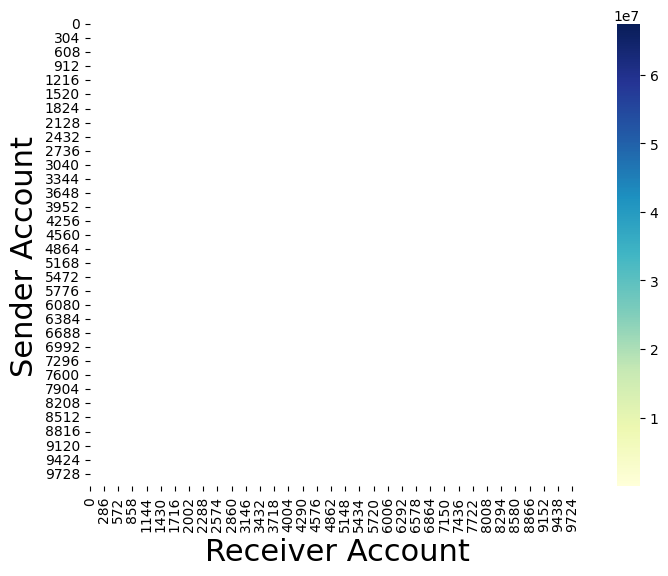

In [34]:
transactions = pd.read_csv('transactions.csv')
orig = "SENDER_ACCOUNT_ID"
dest = "RECEIVER_ACCOUNT_ID"
amnt = "TX_AMOUNT"

users_list = []
for _, row in transactions.iterrows():
    if row[orig] not in users_list:
        users_list.append(row[orig])
    if row[dest] not in users_list:
        users_list.append(row[dest])

id_to_int = {user_id: idx for idx, user_id in enumerate(users_list)} 


rows = len(Y_new)

matrix = np.zeros((rows, rows))

for _, row in transactions.iterrows():
    orig_acct = int(row[orig])
    bene_acct = int(row[dest])
    amount = float(row[amnt])

    matrix[orig_acct][bene_acct] += amount

mask = (matrix == 0) # cover all zeros

plt.figure(figsize=(8, 6))
sns.heatmap(matrix, cmap='YlGnBu', fmt=".2f", cbar=True, mask=mask,
                linewidths=0.5, linecolor='white')

plt.xlabel("Receiver Account", fontsize=22)
plt.ylabel("Sender Account", fontsize=22)
plt.show()

Matrix shape: (10000, 10000)
Total elements: 100000000
Zero elements: 99931053
Sparsity: 0.9993 (99.93% zeros)


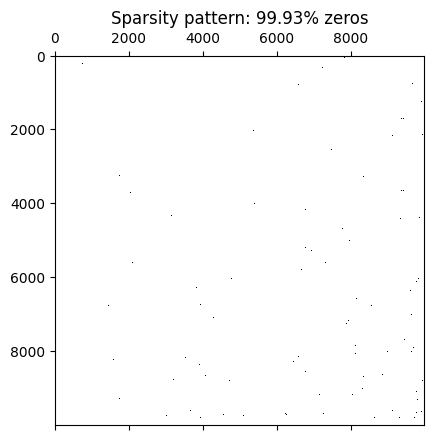

Matrix is sparse (>70.0% zeros). Converting to CSC format.
Memory usage before: 781250.00 KB
Memory usage after: 847.04 KB


In [35]:
from scipy import sparse

total_elements = matrix.size
zero_elements = np.count_nonzero(matrix == 0)
sparsity = zero_elements / total_elements

print(f"Matrix shape: {matrix.shape}")
print(f"Total elements: {total_elements}")
print(f"Zero elements: {zero_elements}")
print(f"Sparsity: {sparsity:.4f} ({sparsity*100:.2f}% zeros)")

# Visualize the matrix (optional)
plt.spy(matrix)
plt.title(f"Sparsity pattern: {sparsity*100:.2f}% zeros")
plt.show()

sparsity_threshold = 0.7

# Convert to sparse if sparsity is above threshold
if sparsity > sparsity_threshold:
    print(f"Matrix is sparse (>{sparsity_threshold*100}% zeros). Converting to CSC format.")
    sparse_matrix = sparse.csc_matrix(matrix)
    print(f"Memory usage before: {matrix.nbytes / 1024:.2f} KB")
    print(f"Memory usage after: {sum(x.nbytes for x in [sparse_matrix.data, sparse_matrix.indices, sparse_matrix.indptr]) / 1024:.2f} KB")
    matrix = sparse_matrix
else:
    print(f"Matrix is not sparse enough (<{sparsity_threshold*100}% zeros). Keeping as dense.")


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.348170e+01
 Y:         10000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.999990e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=1.17e+00 time=7.72e-02
* iter=1 time=1.55e-02 obj=7.69e+06 |delta(obj)|/obj=9.99e-01 nnz(X,L,W)/p=[1.17e+00 6.30e-01 1.00e+00] lns_iter=2 
* iter=2 time=2.12e-02 obj=3.85e+06 |delta(obj)|/obj=9.96e-01 nnz(X,L,W)/p=[1.17e+00 6.30e-01 1.00e+00] lns_iter=2 
* iter=3 time=2.69e-02 obj=1.93e+06 |

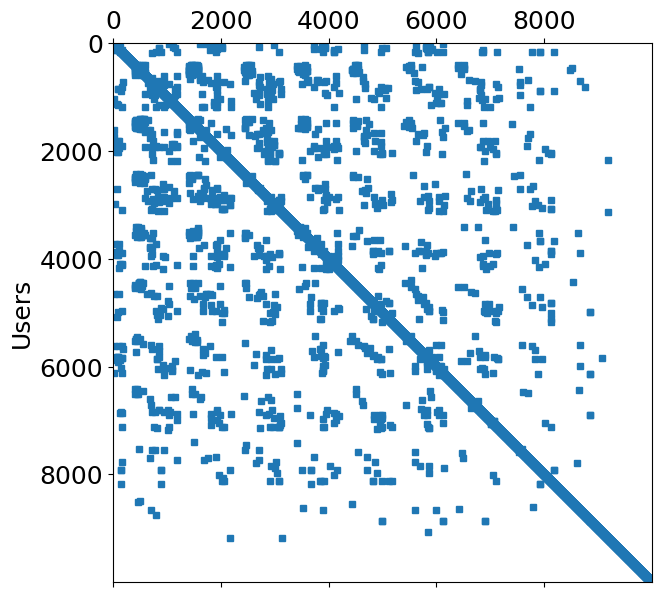

✅ Matrix is symmetric per rho 0.999999

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.348170e+01
 Y:         10000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.999950e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=1.82e+00 time=7.40e-02
* iter=1 time=1.66e-02 obj=7.69e+06 |delta(obj)|/obj=9.99e-01 nnz(X,L,W)/p=[1.82e+00 1.07e+00 1.00e+00] lns_iter=2 
* iter=2 time=2.35e-02 obj=3.85e+06 |delta(obj)|/obj=9.96e-01 nnz(X,L,W)/p=[1.82e+00 1.07e+00 1.00e+00] lns_iter=2

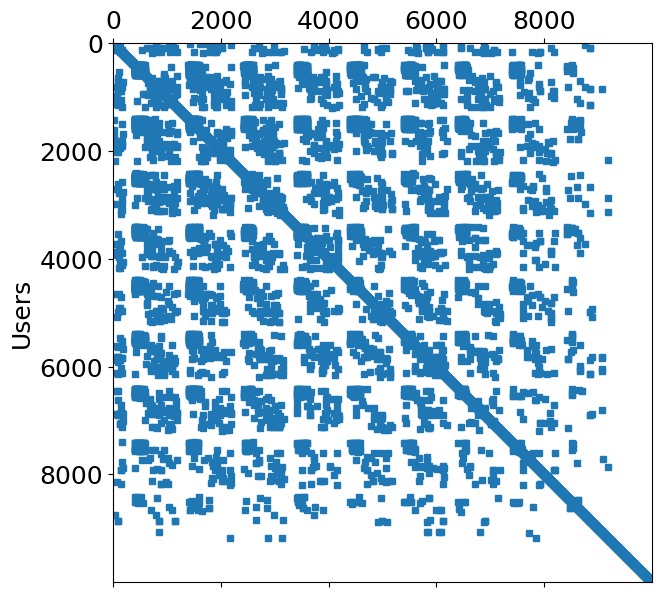

✅ Matrix is symmetric per rho 0.999995

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.348170e+01
 Y:         10000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.999900e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=2.40e+00 time=7.63e-02
* iter=1 time=1.77e-02 obj=7.69e+06 |delta(obj)|/obj=9.99e-01 nnz(X,L,W)/p=[2.40e+00 1.47e+00 1.00e+00] lns_iter=2 
* iter=2 time=2.43e-02 obj=3.85e+06 |delta(obj)|/obj=9.96e-01 nnz(X,L,W)/p=[2.40e+00 1.47e+00 1.00e+00] lns_iter=2

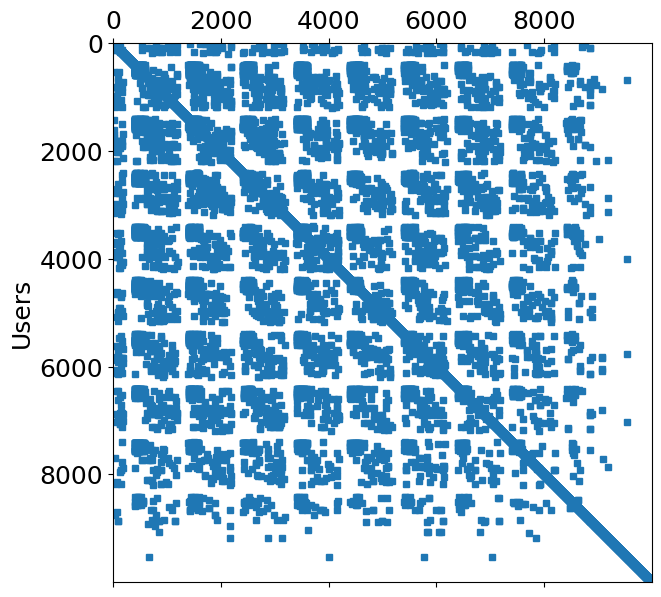

✅ Matrix is symmetric per rho 0.99999

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.348170e+01
 Y:         10000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.999000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=2.09e+01 time=7.77e-02
* iter=1 time=4.32e-02 obj=7.69e+06 |delta(obj)|/obj=9.99e-01 nnz(X,L,W)/p=[2.09e+01 1.22e+01 1.00e+00] lns_iter=2 
* iter=2 time=1.37e-01 obj=3.85e+06 |delta(obj)|/obj=9.96e-01 nnz(X,L,W)/p=[2.09e+01 1.22e+01 1.00e+00] lns_iter=2 

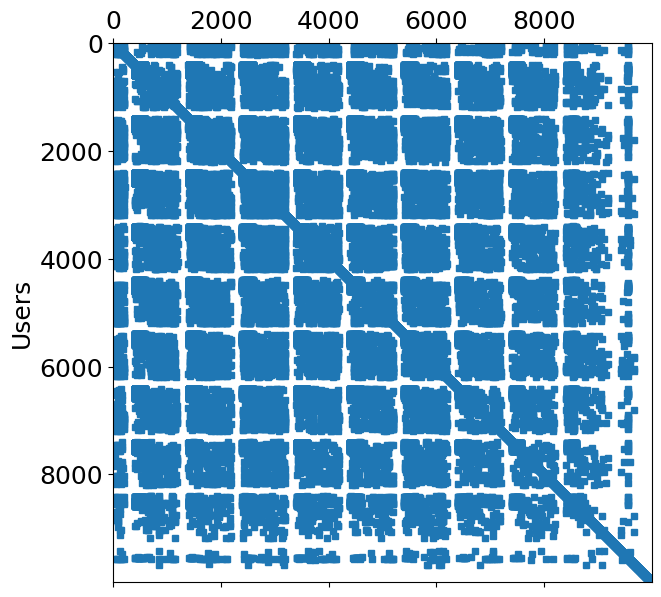

✅ Matrix is symmetric per rho 0.9999


In [36]:
data_nnz = []
data_nnzr = []
data_time = []
data_sym = []

for rho in l:
    fit_norm_dict[rho], end_time = squic_fit_matrix(Y_new, l=rho, matrix=matrix)
    end_time = round(end_time, 2)
    print(f"required time: {end_time}")

    nnz, nnz_r = nnz_fit(fit_norm_dict[rho], ROWS)
    print(f"nnz = {nnz} per rows = {nnz_r}")

    sparsity_pattern(fit_norm_dict[rho])

    if is_symmetric(fit_norm_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sym.append("Yes")
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sym.append("No")

    data_nnz.append(nnz)
    data_nnzr.append(nnz_r)
    data_time.append(end_time)

table_fit_norm = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sym
]


# Table

In [36]:
def table(data, title, l):
    table = tabulate(
        data,
        headers=[title] + l,
        tablefmt="fancy_grid",
        numalign="center",
        stralign="center"
    )
    return table

In [37]:
#print(table(table_squic, "SQUIC", l))

print(table(table_squic_norm, "SQUIC NORM", l))

#print(table(table_fit, "SQUIC FIT", l)) 

print(table(table_fit_norm, "SQUIC FIT NORM", l))

╒══════════════╤══════════╤═════════╤═════════╤═════════╤═════════╤════════╕
│  SQUIC NORM  │  0.9999  │  0.999  │  0.998  │  0.997  │  0.995  │  0.99  │
╞══════════════╪══════════╪═════════╪═════════╪═════════╪═════════╪════════╡
│     NNZ      │   9999   │  9999   │  9999   │  9999   │  9999   │  9999  │
├──────────────┼──────────┼─────────┼─────────┼─────────┼─────────┼────────┤
│   NNZ/Row    │   1.0    │   1.0   │   1.0   │   1.0   │   1.0   │  1.0   │
├──────────────┼──────────┼─────────┼─────────┼─────────┼─────────┼────────┤
│   Time (s)   │   0.37   │  0.54   │  0.92   │  1.25   │   1.6   │  2.15  │
├──────────────┼──────────┼─────────┼─────────┼─────────┼─────────┼────────┤
│  Symmetric   │   Yes    │   Yes   │   Yes   │   Yes   │   Yes   │  Yes   │
╘══════════════╧══════════╧═════════╧═════════╧═════════╧═════════╧════════╛
╒══════════════════╤══════════╤═════════╤═════════╤═════════╤═════════╤════════╕
│  SQUIC FIT NORM  │  0.9999  │  0.999  │  0.998  │  0.997  │  0.995  │ 